This document is meant to test 1D FNO models trained on one grid size on other grid sizes to see to what extent they are discretization invariant.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utilities3 import MatReader
from FNO1D_def import *
import os

In [4]:
#config

modes = 16
width = 64
model_path = "/scratch/mnhagen/models/burgers/with_spatial/FNO1D_heat_eq_128_modes16.pt"
highres_path = "/scratch/mnhagen/datasets/burgers/with_spatial/burgers_1D_256_k64.h5"
resolutions = [32, 64, 128, 256, 512]

In [5]:
model = FNO1D(modes, width).cuda()
model.load_state_dict(torch.load(model_path))
model.eval()

# Load high-res dataset
reader = MatReader(highres_path)
x_full = reader.read_field("a").permute(2,1,0)  # shape: (n_samples, n_points, dim)
y_full = reader.read_field("u").permute(1,0)    # shape: (n_samples, n_points)
n_samples, n_points, _ = x_full.shape

myloss = LpLoss(size_average=True)

print(f"Loaded high-res dataset with {n_points} points")

RuntimeError: Error(s) in loading state_dict for FNO1D:
	Unexpected key(s) in state_dict: "fc1.weight", "fc1.bias". 

In [27]:
#Helper functions

def subsample(x, y, factor):
    """Downsample data by an integer factor."""
    x_sub = x[:, ::factor, :]
    y_sub = y[:, ::factor]
    return x_sub, y_sub

def evaluate_subsampled(model, x_full, y_full, factor, batch_size=20):
    x, y = subsample(x_full, y_full, factor)
    dataset = torch.utils.data.TensorDataset(x, y)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    per_sample_losses = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.cuda(), yb.cuda()
            out = model(xb)
            for i in range(xb.size(0)):
                li = myloss(out[i:i+1].view(1, -1), yb[i:i+1].view(1, -1)).item()
                per_sample_losses.append(li)
    
    per_sample_losses = np.array(per_sample_losses)
    return per_sample_losses.mean(), per_sample_losses.std(), x.shape[1]

In [35]:
# Evaluate across resolutions
results = []
for N in resolutions:
    factor = n_points // N
    mean_l2, std_l2, n_points_eval = evaluate_subsampled(model, x_full, y_full, factor)
    print(f"N = {n_points_eval} | L2 mean loss = {mean_l2:.6f} | std = {std_l2:.6f}")
    results.append((n_points_eval, mean_l2, std_l2))

N = 16 | L2 mean loss = 0.858698 | std = 0.260413
N = 32 | L2 mean loss = 0.408146 | std = 0.091543
N = 64 | L2 mean loss = 0.374712 | std = 0.088750
N = 128 | L2 mean loss = 0.374738 | std = 0.088750
N = 256 | L2 mean loss = 0.374750 | std = 0.088757


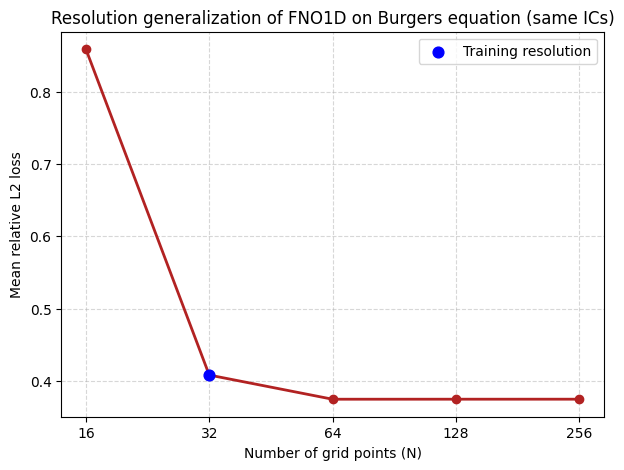

In [36]:
# Plot
plot_errors = False
resolutions, means, stds = zip(*results)
train_N = int(os.path.basename(model_path).split('_')[2])

plt.figure(figsize=(7,5))
plt.plot(resolutions, means, 'o-', color="firebrick", lw=2)
if plot_errors:
    plt.errorbar(resolutions, means, yerr=stds, fmt='o-', color="firebrick", lw=2, capsize=4, label="mean ± std")

if train_N in resolutions:
    i = resolutions.index(train_N)
    plt.scatter(resolutions[i], means[i], color='blue', s=60, zorder=5, label='Training resolution')

plt.xscale('log', base=2)
plt.xticks(resolutions, [str(r) for r in resolutions])
plt.xlabel("Number of grid points (N)")
plt.ylabel("Mean relative L2 loss")
plt.title("Resolution generalization of FNO1D on Burgers equation (same ICs)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()